In [4]:
import sys
print(sys.executable)


c:\Users\souja\anaconda3\python.exe


In [5]:
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm imbalanced-learn shap sqlalchemy psycopg2-binary

  Using cached xgboost-3.4.0-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached xgboost-3.4.0-py3-none-win_amd64.whl (48.9 MB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 460.1 kB/s eta 0:00:05
   ---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

sns.set_style("whitegrid")
%matplotlib inline

url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password="ganesha@03",
    host="localhost",
    port="5432",
    database="finguard_db",
)
engine = create_engine(url)

df = pd.read_sql("SELECT * FROM transactions", engine)
print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


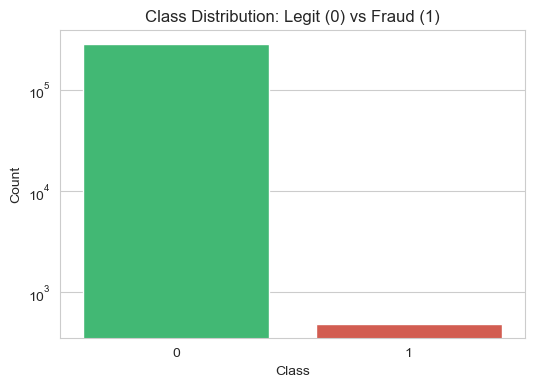

In [2]:
# Class distribution
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {(class_counts[1] / len(df)) * 100:.4f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, hue='Class', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Class Distribution: Legit (0) vs Fraud (1)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.yscale('log')  # log scale needed because fraud is so rare it'd be invisible otherwise
plt.show()

Legit transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


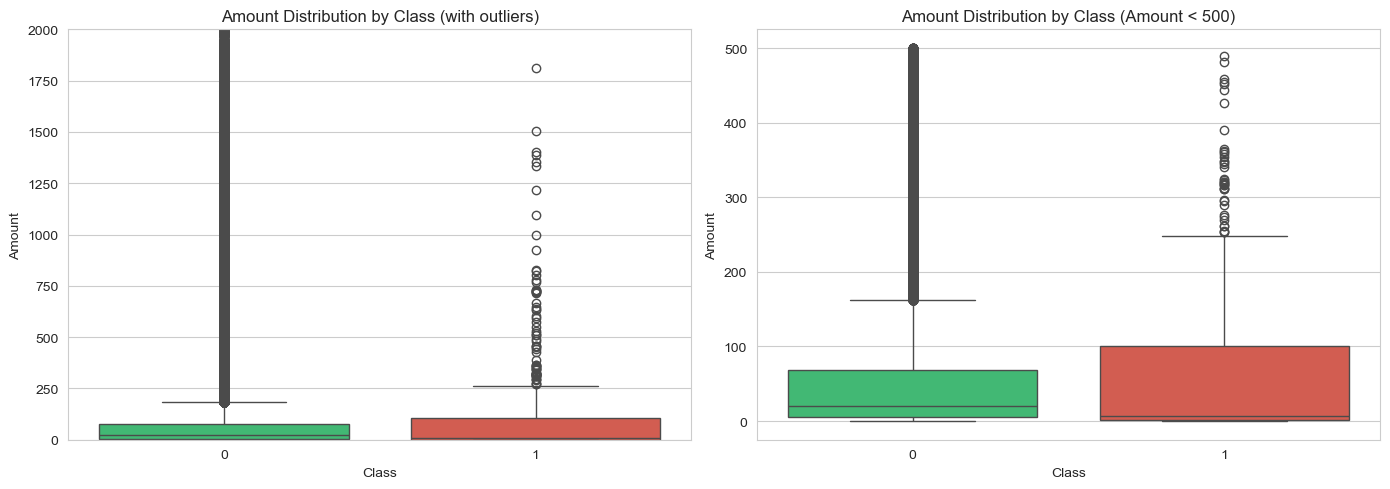

In [3]:
# Amount statistics by class
print("Legit transactions - Amount stats:")
print(df[df['Class'] == 0]['Amount'].describe())

print("\nFraud transactions - Amount stats:")
print(df[df['Class'] == 1]['Amount'].describe())

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Class', y='Amount', data=df, hue='Class', palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[0])
axes[0].set_title('Amount Distribution by Class (with outliers)')
axes[0].set_ylim(0, 2000)  # zoom in, ignore extreme outliers for readability

sns.boxplot(x='Class', y='Amount', data=df[df['Amount'] < 500], hue='Class', palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[1])
axes[1].set_title('Amount Distribution by Class (Amount < 500)')

plt.tight_layout()
plt.show()

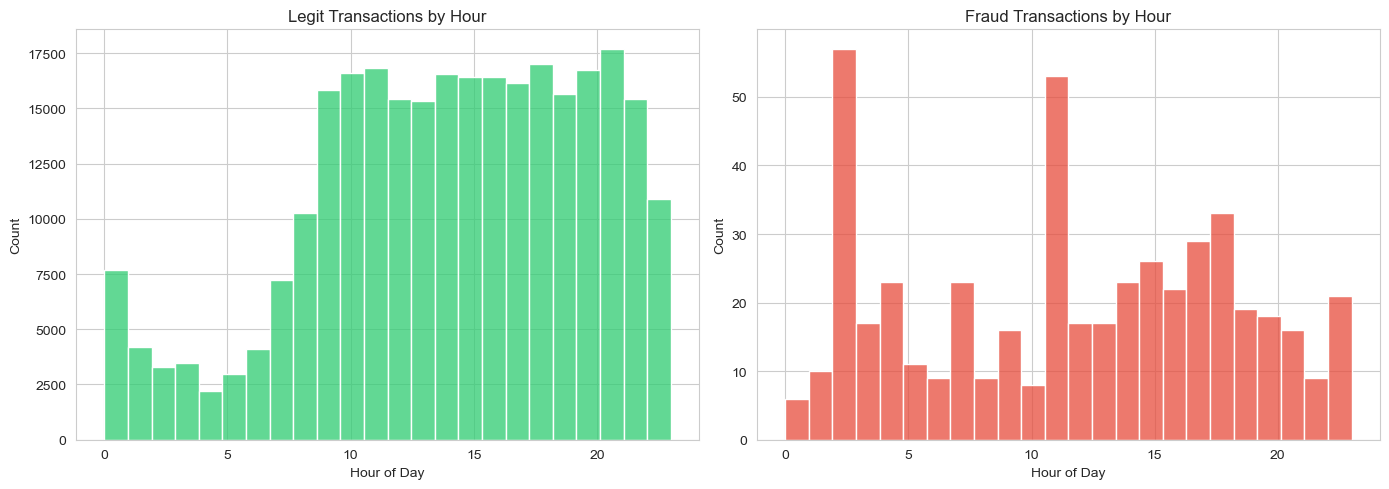

Fraud rate (%) by hour:
Hour
2.0     1.712740
4.0     1.041195
3.0     0.486827
5.0     0.367893
7.0     0.317548
11.0    0.314428
1.0     0.236967
6.0     0.219459
18.0    0.193673
23.0    0.191991
17.0    0.179389
15.0    0.157949
14.0    0.138805
16.0    0.133714
19.0    0.121414
13.0    0.110641
12.0    0.110246
20.0    0.107424
9.0     0.101023
21.0    0.090380
8.0     0.087583
0.0     0.077973
22.0    0.058286
10.0    0.048199
Name: Class, dtype: float64


In [4]:
# Convert Time (seconds) into hour-of-day (data spans ~48 hours)
df['Hour'] = (df['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['Class'] == 0]['Hour'], bins=24, color='#2ecc71', ax=axes[0])
axes[0].set_title('Legit Transactions by Hour')
axes[0].set_xlabel('Hour of Day')

sns.histplot(df[df['Class'] == 1]['Hour'], bins=24, color='#e74c3c', ax=axes[1])
axes[1].set_title('Fraud Transactions by Hour')
axes[1].set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()

# Fraud rate per hour (more informative than raw counts)
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100
print("Fraud rate (%) by hour:")
print(fraud_rate_by_hour.sort_values(ascending=False))

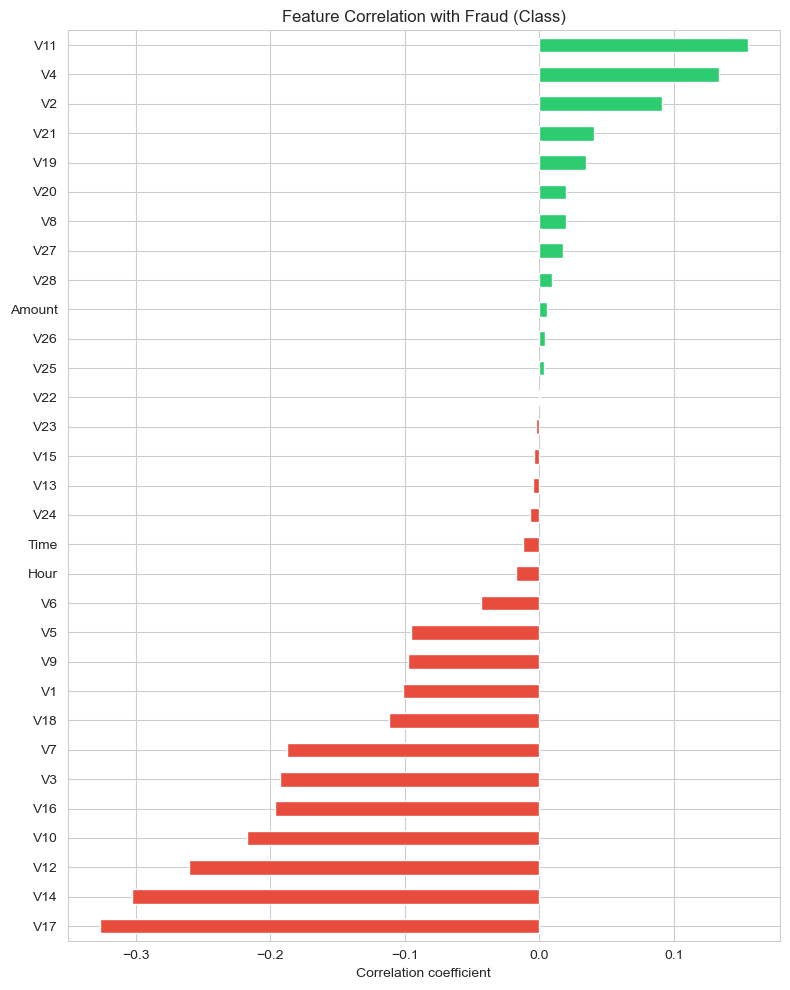

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [5]:
# Correlation of each feature with the target (Class)
corr_with_class = df.corr(numeric_only=True)['Class'].drop('Class').sort_values()

plt.figure(figsize=(8, 10))
corr_with_class.plot(kind='barh', color=['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_class])
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print(corr_with_class.sort_values(key=abs, ascending=False).head(10))